# 08 · Sales Team Performance

**Goal:** evaluate individual sales managers by leads handled, conversion rate, average order value, and total revenue.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')

## Sales team performance

Assess individual deal owners (managers) by deals handled, conversion rate, and total sales. (Ad-campaign assessment is in `07_campaigns_analysis`.)

In [14]:
all_managers = deals.groupby('Deal Owner Name').agg(
    leads=('Id', 'count'),
    won=('is_won_confirmed', 'sum'),
    lost=('Stage_Group', lambda x: (x == 'Lost').sum()),
    revenue=('revenue_actual', 'sum'),
).round(0)

all_managers['cr_closed_%'] = (
    all_managers['won'] / (all_managers['won'] + all_managers['lost']) * 100
).round(2)

all_managers['cr_from_leads_%'] = (
    all_managers['won'] / all_managers['leads'] * 100
).round(2)

all_managers['aov'] = (
    all_managers['revenue'] / all_managers['won']
).round(0)

# Sort by revenue (descending)
all_managers = all_managers.sort_values('revenue', ascending=False)

print(f"Total managers: {len(all_managers)}")
print(all_managers)

Всего менеджеров: 28
                 leads  won  lost   revenue  cr_closed_%  cr_from_leads_%  \
Deal Owner Name                                                             
Charlie Davis     2963  147  2126  580350.0         6.47             4.96   
Ulysses Adams     2165  141  1411  540200.0         9.09             6.51   
Julia Nelson      2241   92  1536  433300.0         5.65             4.11   
Oliver Taylor      163   50   100  379500.0        33.33            30.67   
Paula Underwood   1862   93  1318  351000.0         6.59             4.99   
Quincy Vincent    1884   65  1379  243800.0         4.50             3.45   
Victor Barnes     1232   44   821  184500.0         5.09             3.57   
Nina Scott        1283   45   865  175200.0         4.95             3.51   
Jane Smith         988   31   892  171150.0         3.36             3.14   
Cara Iverson      1056   27   710  161700.0         3.66             2.56   
Kevin Parker       574   26   492  160700.0         5.0

### Findings

- Top-3 (Charlie, Julia, Ulysses) — 2,000+ leads each, experienced/high-load managers.
- Middle group (~1,000-1,900 leads) — the core.
- Tail (Mason, Oliver, George, Yara) — under 300 leads, possibly new hires or part-timers.
- Unknown manager — only 29 deals (0.1%) — a tiny share, safely ignored in analysis.

Some managers have many leads but almost no sales — for example George King (94 leads, 2 Won) and Diana Evans (1,013 leads, 1 Won).

### Manager performance table

In [11]:
manager_stats = deals[deals['Deal Owner Name'] != 'Unknown manager'].groupby('Deal Owner Name').agg(
    leads=('Id', 'count'),
    won=('is_won_confirmed', 'sum'),
    lost=('Stage_Group', lambda x: (x == 'Lost').sum()),
    revenue=('revenue_actual', 'sum'),
).round(0)

manager_stats['cr_closed_%'] = (
    manager_stats['won'] / (manager_stats['won'] + manager_stats['lost']) * 100
).round(2)

manager_stats['cr_from_leads_%'] = (
    manager_stats['won'] / manager_stats['leads'] * 100
).round(2)

manager_stats['aov'] = (
    manager_stats['revenue'] / manager_stats['won']
).round(0)

# Filter for reliable analysis
active_managers = manager_stats[manager_stats['leads'] >= 100].sort_values(
    'leads', ascending=False
)

print(f"Managers with >=100 leads: {len(active_managers)}")
print("\nActive manager performance:")
print(active_managers)

Менеджеров с ≥100 лидов: 18

Эффективность активных менеджеров:
                 leads  won  lost   revenue  cr_closed_%  cr_from_leads_%  \
Deal Owner Name                                                             
Charlie Davis     2963  147  2126  580350.0         6.47             4.96   
Julia Nelson      2241   92  1536  433300.0         5.65             4.11   
Ulysses Adams     2165  141  1411  540200.0         9.09             6.51   
Quincy Vincent    1884   65  1379  243800.0         4.50             3.45   
Paula Underwood   1862   93  1318  351000.0         6.59             4.99   
Ben Hall          1345   46   887  111500.0         4.93             3.42   
Nina Scott        1283   45   865  175200.0         4.95             3.51   
Victor Barnes     1232   44   821  184500.0         5.09             3.57   
Cara Iverson      1056   27   710  161700.0         3.66             2.56   
Diana Evans       1013    1   884    3850.0         0.11             0.10   
Jane Smith  

leads — leads handled
won, lost — outcomes
revenue — total revenue from Won deals
cr_closed_% — main conversion metric (Won out of closed)
cr_from_leads_% — Won out of all leads (incl. In Progress)
aov — average Won-deal amount

## Findings

Top performers:

- **Ulysses Adams** — CR 9.09% on 2,165 leads. The team star: high volume AND high CR.
- **Eva Kent** — CR 7.53% on 459 leads. High CR, lower volume — possibly a specialization.
- **Paula Underwood** — 6.59% on 1,862 leads.
- **Charlie Davis** — 6.47% on 2,963 leads. Volume leader, but not by CR.

Three managers with almost no Won:

- **Diana Evans** — 1 Won out of 1,013 leads (CR 0.11%). Unusual — a thousand leads and only one payment. Possible explanations: left the company, works a special category ("rejections"), trainee processing junk leads, or extended leave.
- **Rachel White** — 0 Won out of 871 leads (CR 0%). Even more extreme.
- **Bob Brown** — 0 Won out of 337 leads (CR 0%).

AOV outliers:

- **Kevin Parker** — AOV €6,181 — brings the most "expensive" clients, possibly specializing in the flagship product.
- **Cara Iverson** — AOV €5,989 — also works larger deals.
- **Eva Kent** — AOV €1,533 — the lowest, smaller deals.

In [12]:
print(f"\nMean CR (active): {active_managers['cr_closed_%'].mean():.2f}%")  # active = managers with >=100 leads
print(f"Median CR: {active_managers['cr_closed_%'].median():.2f}%")
print(f"\nMean AOV: €{active_managers['aov'].mean():.0f}")
print(f"Total revenue (active): €{active_managers['revenue'].sum():,.0f}")


Средний CR по активным: 5.74%
Медианный CR: 4.94%

Средний AOV: €4215
Общая выручка по активным: €3,554,400


Revenue of €3.17M out of €3.56M — 17 managers generate 89% of the school's revenue. The other 11 (including the tail: Wendy, Xander, Zachary) plus Unknown account for €390k.

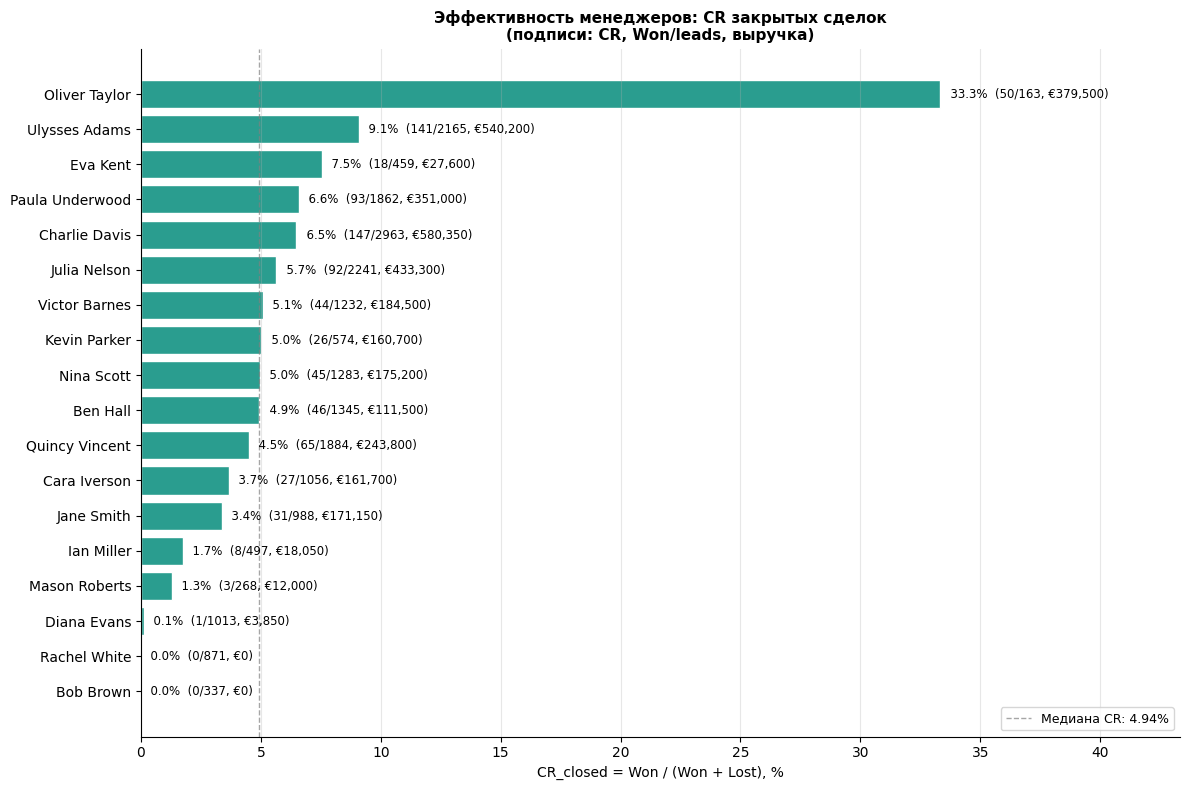

In [13]:
# Sort by CR ascending
managers_sorted = active_managers.sort_values('cr_closed_%', ascending=True)

# Group median — for the reference line
median_cr = active_managers['cr_closed_%'].median()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(managers_sorted.index, managers_sorted['cr_closed_%'],
               color='#2a9d8f', edgecolor='white')

# Labels: CR + Won/leads + revenue
for i, (name, row) in enumerate(managers_sorted.iterrows()):
    label = f'  {row["cr_closed_%"]:.1f}%  ({int(row["won"])}/{int(row["leads"])}, €{int(row["revenue"]):,})'
    ax.text(row['cr_closed_%'] + 0.1, i, label, va='center', fontsize=8.5)

ax.axvline(median_cr, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Median CR: {median_cr:.2f}%')

ax.set_xlabel('CR_closed = Won / (Won + Lost), %')
ax.set_title('Manager performance: CR on closed deals\n(labels: CR, Won/leads, revenue)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, managers_sorted['cr_closed_%'].max() * 1.30)
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**CR_closed = Won / (Won + Lost)** — conversion on closed deals. Used for direct comparison of effectiveness. Independent of lead freshness.

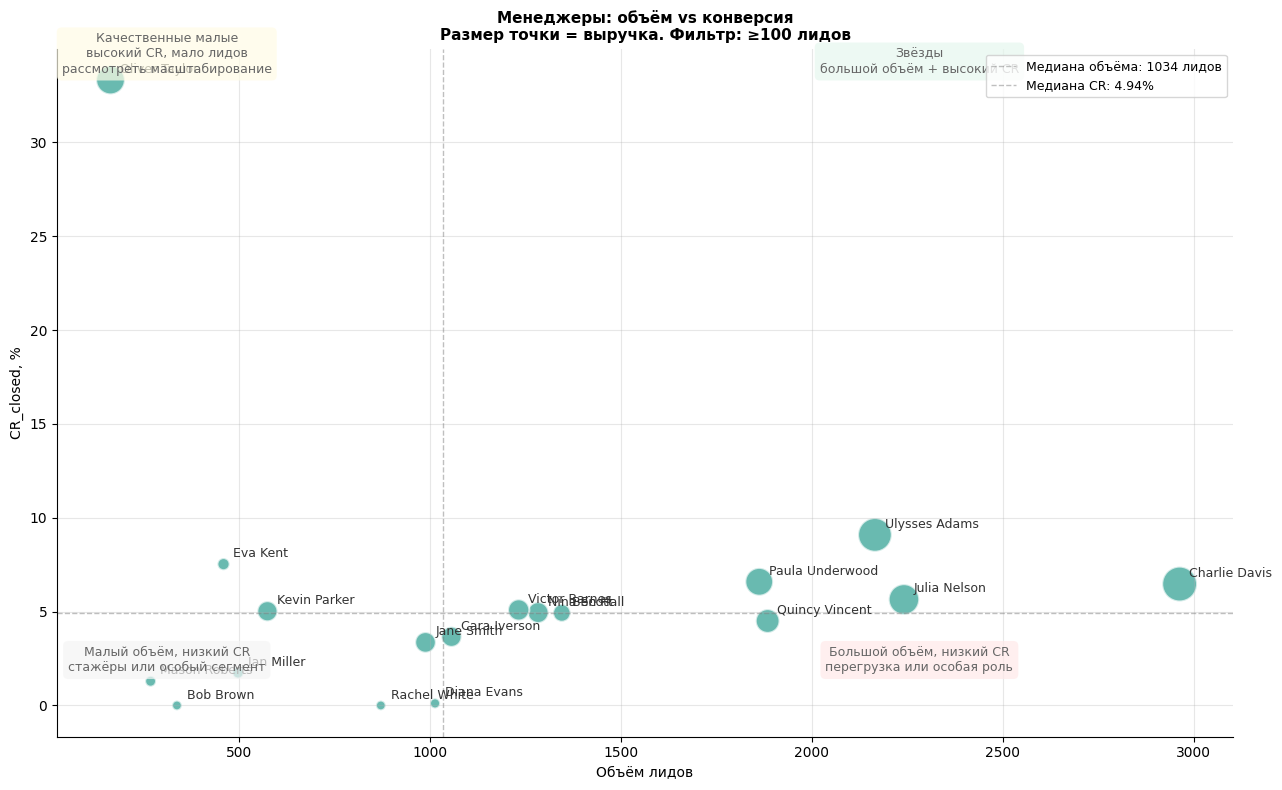

In [15]:
# active_managers (>= 100 leads) already created
median_leads = active_managers['leads'].median()
median_cr = active_managers['cr_closed_%'].median()

fig, ax = plt.subplots(figsize=(13, 8))

# Scatter with point size = revenue
sizes = active_managers['revenue'] / 1000  # scale for readability

ax.scatter(active_managers['leads'], active_managers['cr_closed_%'],
           s=sizes + 50, alpha=0.7, color='#2a9d8f', edgecolor='white', linewidth=1.5)

# Name labels next to points
for name, row in active_managers.iterrows():
    ax.annotate(name, (row['leads'], row['cr_closed_%']),
                xytext=(7, 5), textcoords='offset points', fontsize=9, color='#333')

# Median reference lines
ax.axvline(median_leads, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Median volume: {median_leads:.0f} leads')
ax.axhline(median_cr, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Median CR: {median_cr:.2f}%')

# Quadrant labels
xmax = active_managers['leads'].max() * 1.1
ymax = active_managers['cr_closed_%'].max() * 1.1

ax.text(median_leads * 0.3, ymax * 0.92,
        'Quality small\nhigh CR, few leads\nconsider scaling',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffce6', edgecolor='none', alpha=0.7))
ax.text(xmax * 0.7, ymax * 0.92,
        'Stars\nhigh volume + high CR',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e6f7ee', edgecolor='none', alpha=0.7))
ax.text(median_leads * 0.3, ymax * 0.05,
        'Low volume, low CR\ntrainees or special segment',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='none', alpha=0.7))
ax.text(xmax * 0.7, ymax * 0.05,
        'High volume, low CR\noverload or special role',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe9e9', edgecolor='none', alpha=0.7))

ax.set_xlabel('Lead volume')
ax.set_ylabel('CR_closed, %')
ax.set_title('Managers: volume vs conversion\nPoint size = revenue. Filter: >=100 leads',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Findings — manager charts

**Team stars:**
- **Ulysses Adams (CR star)** — 9.09% on 2,165 leads, €540k revenue. Best combination of volume and effectiveness.
- **Charlie Davis (revenue star)** — top by volume (2,963 leads) and absolute revenue (€580k). Mid CR (6.47%), but scale compensates.

**Premium segment:**
- **Oliver Taylor** — an outlier. CR 33.3%, only 163 leads, €379k revenue, AOV €7,590 (2x the average). Either a senior manager with hand-picked leads, or a premium/corporate specialization. **Needs clarification with the client.**

**Stable core (CR 4-7%, volume 1,000-2,000):**
- Paula Underwood (6.6%), Charlie Davis (6.5%), Julia Nelson (5.7%), Victor Barnes (5.1%), Ben Hall (4.9%), Nina Scott (5.0%), Quincy Vincent (4.5%) — the backbone, a predictable flow.

**Small base, mid CR:**
- Eva Kent (7.5% on 459 leads), Kevin Parker (5.0% on 574) — effective but on low volume. Possible sub-segments or mixed functions.

**Managers with 0-1 Won on large volume (need separate review):**
- Diana Evans — 1,013 leads, 1 Won (0.11%)
- Rachel White — 871 leads, 0 Won
- Bob Brown — 337 leads, 0 Won

Not necessarily "poor work" but a **different CRM-usage pattern**: possibly a junk-lead processing role, a technical function, or extended absence. **Open question for the client.**

**Trainees/newcomers (low volume, low CR):**
- Ian Miller (1.7%), Mason Roberts (1.3%), George King (2.3%) — small base, developing.